## 2D Orzag-Tang vortex evolution

In this example we simulate a modified Orzag-Tang vortex (given in *Loureiro et al. 2016, Comput. Phys. Commun. 206 (2016): 45-63*):
$\Phi = \cos(x+1.4) + \cos(y + 0.5), \quad \Psi = \cos(2x+2.3)+\cos(x+4.1)$

In [6]:
import jax_rmhd as jr
from typing import NamedTuple, Tuple
import jax
from jax import jit
import jax.numpy as jnp
import jax.numpy.fft as ft
from functools import partial
import matplotlib.pyplot as plt
import orbax.checkpoint as ocp
import os
import jax_rmhd.snapshot_io as sn
import jax_rmhd.physics as phys #need this if you want to test out the physics steps
import jax_rmhd.diagnostics as diag

In [8]:
#parameters
nx = 256
ny = 256
Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
dx = Lx/nx
nupar = 1e-4
dt = 0.01
t = 0.0
nsnap = 100
t_snap=1.0
t_end=10.0
cfl_safety=1.0 #this is pretty aggressive
snap_path="data/orzag-tang-2D/"

#we will use hyperviscosity
visc=1e-9
res=1e-9
hyper=3

x = jnp.linspace(0, Lx, nx, endpoint=False)
y = jnp.linspace(0, Ly, ny, endpoint=False)
x_grid = x.reshape(-1,1)
y_grid = y.reshape(1,-1)

#initialize arrays
#modified Orzag-Tang vortex as described in Loureiro et al. 2016 (Viriato paper)
phi = jnp.cos(x_grid+1.4) + jnp.cos(y_grid+0.5)
psi = jnp.cos(2.0*x_grid+2.3) + jnp.cos(y_grid + 4.1)

#fft
phik=ft.rfft2(phi)
psik=ft.rfft2(psi)

#set up orbax snapshot manager
mngr=jr.snapshot_manager_setup(snap_path=snap_path,nsnap=nsnap)

#prepare necessary objects for simulation
params=jr.Parameters(nx=nx,ny=ny,Lx=Lx,Ly=Ly,visc=visc,res=res,hyper=hyper,cfl_safety=cfl_safety)
kgrid = jr.setup_kgrids(params)
state = jr.SimulationState(t=0.0,fields=jr.Fields(phik,psik))

In [9]:
#do the simulation
jr.simulate(state,kgrid,params,t_snap=t_snap,t_end=t_end,mngr=mngr)

Saving initial state as snapshot 0
---COMPILING rk_advance---
Saving snapshot 1 at t = 1.0042293047804756
---COMPILING rk_advance---
Saving snapshot 2 at t = 2.007945525491138
Saving snapshot 3 at t = 3.009624752911591
Saving snapshot 4 at t = 4.010756953920215
Saving snapshot 5 at t = 5.0107630222232
Saving snapshot 6 at t = 6.015334484651073
Saving snapshot 7 at t = 7.019537351615869
Saving snapshot 8 at t = 8.021861133043025
Saving snapshot 9 at t = 9.023739299595958
Saving snapshot 10 at t = 10.02387313803503


'Ending simulation at t = 10.02387313803503'

In [10]:
#Making some snapshots.
for isnap in range(0,11):
    snap=sn.load_snapshot(isnap,mngr,params)
    #vort=ft.irfft2(-kgrid.ksq()*snap.fields.phik)
    #vsq=jnp.sum(jnp.array(jax.tree_util.tree_map(lambda gfk: ft.irfft2(gfk),gradk(snap.fields.phik,kgrid)))**2.0,axis=0)
    vort=ft.irfft2(-kgrid.ksq()*snap.fields.phik)
    plt.imshow(vort,vmin=-50,vmax=50,cmap="afmhot")
    plt.colorbar()
    plt.savefig(snap_path+str(isnap).zfill(3)+".png")
    plt.close('all')

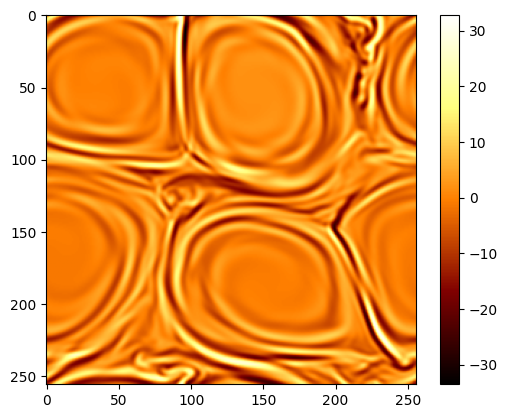

In [11]:
#Plot one of them here
isnap=8
snap=sn.load_snapshot(isnap,mngr,params)
vort=ft.irfft2(-kgrid.ksq()*snap.fields.phik)
plt.imshow(vort,cmap="afmhot")
plt.colorbar()

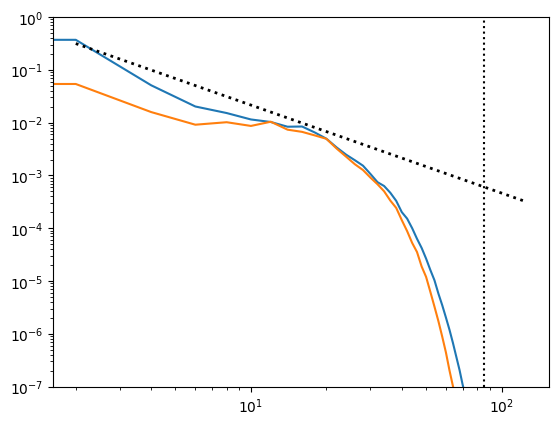

In [13]:
#plot the energy spectrum
isnap=8
snap=sn.load_snapshot(isnap,mngr,params)
k=jnp.array(range(0,params.nx//2,2)) # bin_factor in the spec routine is set to 2 by default
su,sb=diag.spec(snap,kgrid,params)
plt.loglog(k,sb)
plt.loglog(k,su)
plt.ylim(1e-7,1)
plt.loglog(k,k**(-5.0/3.0),'k:',linewidth=2)
plt.loglog([params.nx//3,params.nx//3],[1e-7,1],'k:')

In [12]:
#This makes a gif of the snapshot images if you have imagemagick installed
os.system("cd " + snap_path + ";"
          + "magick -delay 10 -loop 0 *.png orzag-tang-2D.gif;"
         + "cd ../../")

0

Things to mess with if you want to:
- Experiment with different dissipation parameters `visc`,`res`,`hyper`
- Check how the energy in the box evolves (There is a function `energy` in `jax_rmhd.diagnostics.py`)